# Chapter 0: Some Underlying Geometric Notions

**Source Span.** `Algebraic Topology.pdf` printed pages `1-20`.

**Chapter Goal.** Turn the preliminary geometric language into a working toolkit: homotopy type, CW construction, quotient models, space operations, collapse moves, mapping cylinders/cones, and the homotopy extension property.

This notebook uses the source only for structure and terminology. The prose, finite models, diagrams, and checks are original teaching material. The theme is not to memorize a list of spaces, but to learn what each construction preserves, what it collapses, and which finite invariant or proof diagram lets us inspect the move.


In [1]:
from pathlib import Path
import sys, json, math
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Polygon, Rectangle, FancyArrowPatch
import networkx as nx
import plotly.graph_objects as go
from IPython.display import Markdown, display
UNIT_KEY="chapter-00-some-underlying-geometric-notions"; UNIT_TITLE="Chapter 0: Some Underlying Geometric Notions"; SOURCE_PRINTED=(1,20)
PAL={"ink":"#263238","blue":"#3b6ea8","teal":"#2f8f83","gold":"#d99b2b","red":"#b94b5f","gray":"#6d7a80"}
def locate_book_root():
    for c in [Path.cwd(), *Path.cwd().parents]:
        if (c/'AGENTS.md').exists() and (c/'source_map.json').exists(): return c.resolve()
        n=c/'Algebraic-Topology'
        if (n/'AGENTS.md').exists() and (n/'source_map.json').exists(): return n.resolve()
    raise RuntimeError('book root not found')
BOOK_ROOT=locate_book_root(); sys.path.insert(0,str(BOOK_ROOT)) if str(BOOK_ROOT) not in sys.path else None
from utils.artifacts import chapter_artifact_root, save_json, save_csv, save_matplotlib, save_plotly_html, display_artifact, assert_artifacts
ART=chapter_artifact_root(UNIT_KEY, BOOK_ROOT); FIGURES,HTML,CHECKS,TABLES=(ART/n for n in ['figures','html','checks','tables'])
created=[]; checks={}
def track(p): created.append(Path(p)); return Path(p)
plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'white','font.size':10})
print(f'{UNIT_TITLE} artifacts -> {ART.relative_to(BOOK_ROOT)}')


Chapter 0: Some Underlying Geometric Notions artifacts -> artifacts\chapter-00-some-underlying-geometric-notions


## Standalone Coverage Notes

Chapter 0 is a compact preview of the geometric grammar used throughout the book. Homotopy is presented first because later invariants are intended to ignore inessential bending, stretching, and cellwise refinements. Contractible spaces, deformation retracts, and homotopy equivalences are therefore not vocabulary decorations: they are the tests that decide whether a complicated model may be replaced by a simpler one. The notebook treats the house-with-two-rooms idea as a warning that contractibility can be subtle, then shifts to finite CW data where the mechanism is inspectable.

CW complexes are the chapter's main organizing device. A learner should leave this chapter knowing how a skeleton grows by attaching disks, how a characteristic map records the attaching data, and why closure and weak-topology conditions matter. The cell-incidence diagram and boundary check are finite witnesses for this logic. They also prepare the reader for homology, where the same incidence signs become chain maps. The Euler characteristic appearing here is not yet a theorem about homology; it is a first numerical trace of cell structure.

The quotient-space examples explain why algebraic topology prefers models such as polygonal surfaces, projective-space quotients, cones, suspensions, joins, wedges, and smash products. Each construction has two faces: a geometric picture and a formal quotient recipe. The notebook pairs those faces so a reader can ask what points are identified, what new cells are introduced, and what homotopy type is plausibly preserved. Collapse criteria, mapping cylinders, mapping cones, and the homotopy extension property then supply the proof technology that keeps quotient operations from becoming uncontrolled.


## Section-By-Section Coverage Map

The opening homotopy section is covered by the roadmap, the deformation language in the translation guide, and the collapse lab. It distinguishes a mere continuous deformation from a homotopy equivalence and keeps contractibility separate from an obvious deformation retract. The CW section is covered by the skeleta diagram, the characteristic-map image, the incidence graph, the Euler characteristic check, and the boundary-square-zero calculation. These pieces give the reader a reusable way to parse a cell structure before any homology groups appear.

The operations-on-spaces section is covered by the quotient and operation lab. Products are treated as the starting point for cone, suspension, join, wedge, and smash-style constructions; the lab emphasizes which coordinates are retained and which subspaces are collapsed. The surface and projective quotient panel covers polygon models for tori and higher genus surfaces, plus the disk-boundary identification pattern behind real projective space. The collapse section is represented by a graph example and a rank invariant, matching the chapter's message that a contractible subcomplex can simplify a CW pair without erasing the homotopy type.

The mapping-cylinder, mapping-cone, and homotopy-extension sections are covered by the final proof-tool visual. A mapping cylinder replaces an arbitrary map by an inclusion followed by a deformation retract; a mapping cone records a quotient of the source end; HEP explains how a homotopy on a subcomplex can extend across new cells. These proof devices are deliberately presented together because later chapters use them as one coordinated technology.


## Computational Translation Guide

- A homotopy is represented by sampled paths with endpoint checks.
- A CW complex is represented by cells, incidence data, skeleta, characteristic maps, and exact boundary matrices.
- Quotient constructions are represented by edge identifications and explicit cell counts.
- Collapse and extension theorems are represented by dependency diagrams plus invariant checks such as Euler characteristic and boundary-square-zero.


## Chapter-Specific Library Routing

This chapter uses NetworkX for proof dependencies, Matplotlib for durable quotient/CW diagrams, Plotly for operation labs, and SymPy/NumPy for exact finite checks.


In [2]:
routing=[
 {'concept':'homotopy type','representation':'proof roadmap','library':'NetworkX/Matplotlib','artifact':'figures/homotopy-type-roadmap.png'},
 {'concept':'CW construction','representation':'skeleta, cells, boundary matrices','library':'NetworkX/SymPy','artifact':'figures/cw-skeleta-and-characteristic-maps.png'},
 {'concept':'quotient surfaces','representation':'polygon labels and cell counts','library':'Matplotlib/NumPy','artifact':'figures/surface-polygon-quotients.png'},
 {'concept':'space operations','representation':'cone, suspension, wedge lab','library':'Plotly','artifact':'html/space-operations-lab.html'},
 {'concept':'collapses and proof devices','representation':'collapse, mapping cone, HEP diagrams','library':'NetworkX/Matplotlib','artifact':'figures/collapsing-subcomplexes-invariants.png'},
]
routing_path=track(save_csv(routing, TABLES/'chapter0-library-routing.csv'))
display(Markdown('| Concept | Representation | Library | Artifact |\n| --- | --- | --- | --- |\n'+'\n'.join(f"| {r['concept']} | {r['representation']} | {r['library']} | `{r['artifact']}` |" for r in routing)))


| Concept | Representation | Library | Artifact |
| --- | --- | --- | --- |
| homotopy type | proof roadmap | NetworkX/Matplotlib | `figures/homotopy-type-roadmap.png` |
| CW construction | skeleta, cells, boundary matrices | NetworkX/SymPy | `figures/cw-skeleta-and-characteristic-maps.png` |
| quotient surfaces | polygon labels and cell counts | Matplotlib/NumPy | `figures/surface-polygon-quotients.png` |
| space operations | cone, suspension, wedge lab | Plotly | `html/space-operations-lab.html` |
| collapses and proof devices | collapse, mapping cone, HEP diagrams | NetworkX/Matplotlib | `figures/collapsing-subcomplexes-invariants.png` |

## Visual Storyboard

1. Build a roadmap from homotopy type to CW pairs and extension arguments.
2. Construct a CW complex from cells and verify `partial^2 = 0`.
3. Compare polygon quotient models.
4. Explore cone, suspension, and wedge constructions.
5. Collapse contractible subcomplexes while tracking invariants.
6. Separate mapping cylinders, mapping cones, and HEP as proof devices.


## 1. Homotopy Type And CW Skeleta

Homotopy type gives permission to simplify a space; CW skeleta make the simplification cellwise. The two visuals below connect the proof vocabulary to concrete incidence data.


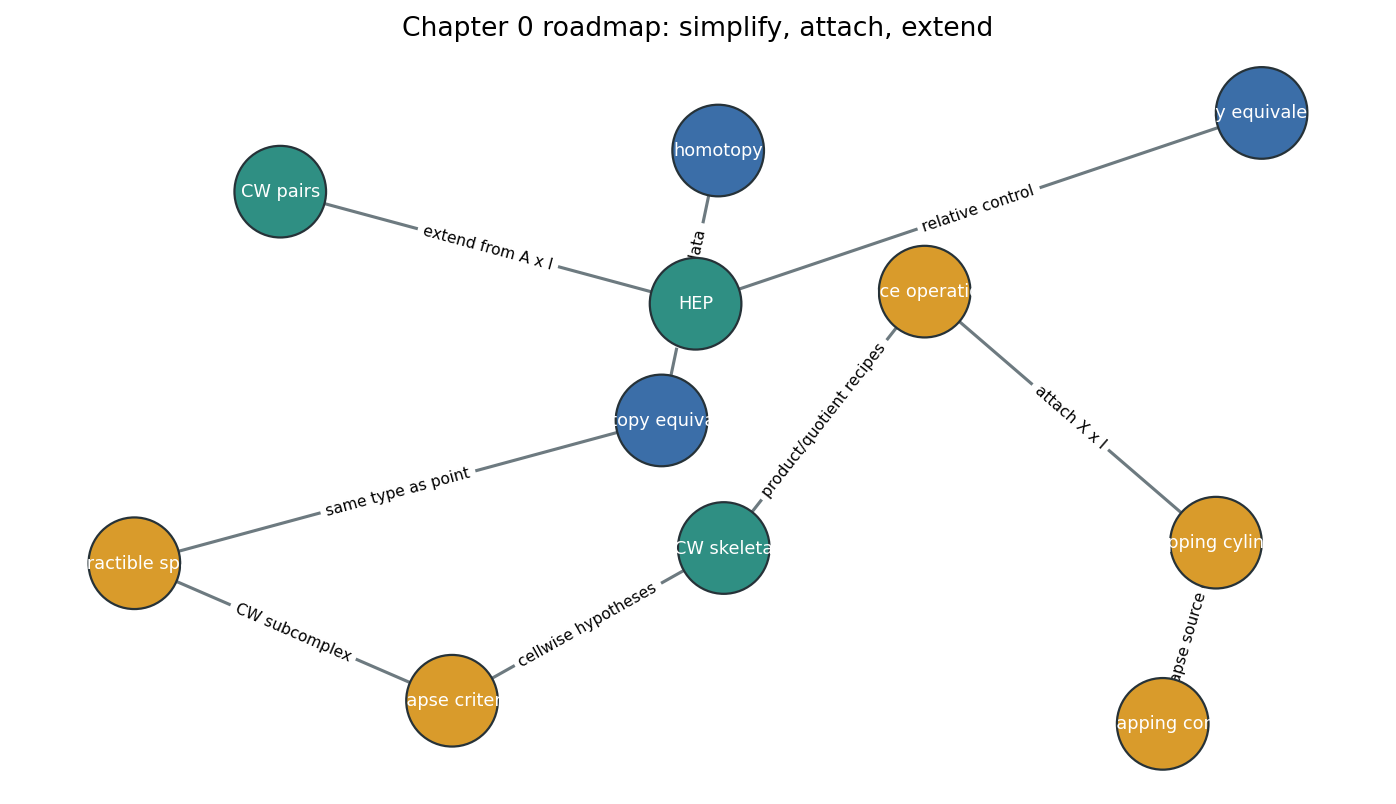

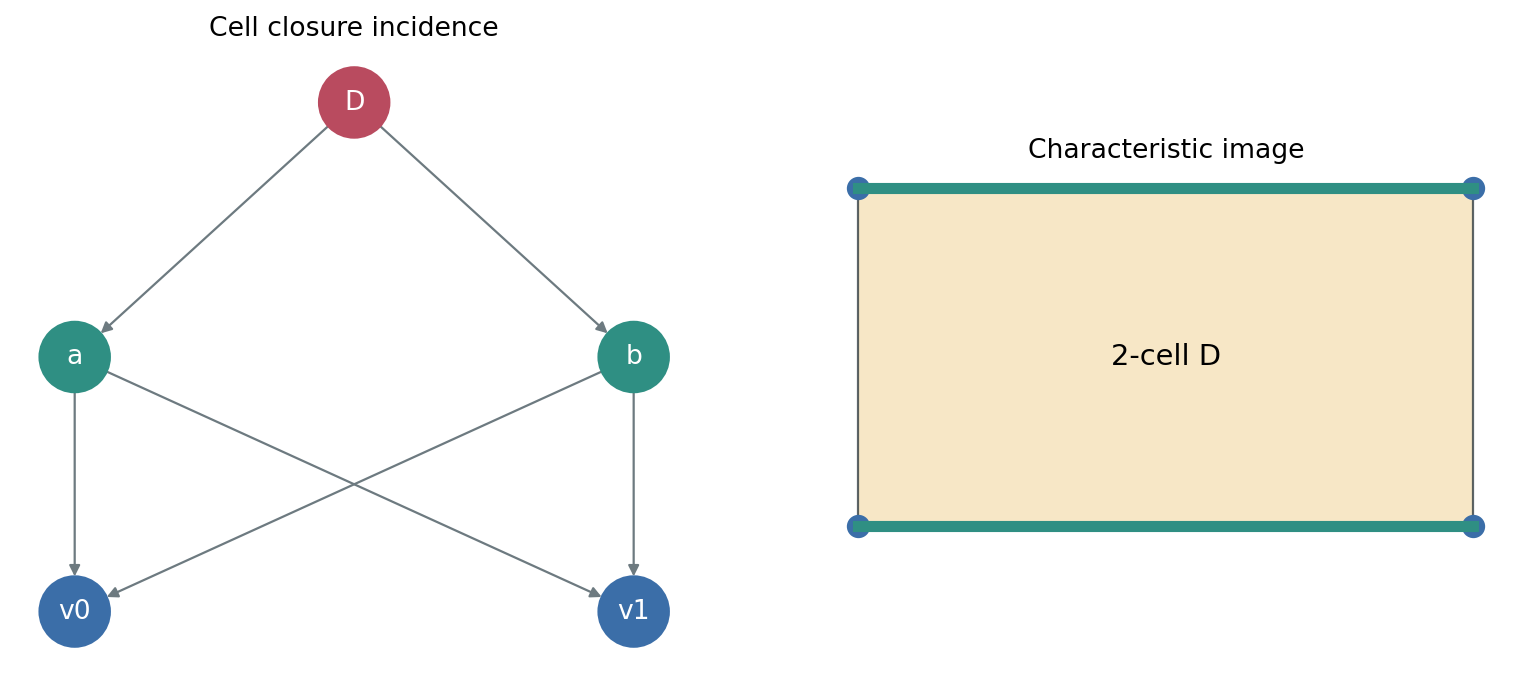

In [3]:
# Roadmap from homotopy type to CW proof tools.
edges=[('homotopy','homotopy equivalence','two-sided data'),('homotopy equivalence','contractible spaces','same type as point'),('contractible spaces','collapse criterion','CW subcomplex'),('CW skeleta','collapse criterion','cellwise hypotheses'),('CW skeleta','space operations','product/quotient recipes'),('space operations','mapping cylinder','attach X x I'),('mapping cylinder','mapping cone','collapse source end'),('CW pairs','HEP','extend from A x I'),('HEP','homotopy equivalence tests','relative control')]
G=nx.DiGraph(); [G.add_edge(u,v,label=l) for u,v,l in edges]
pos=nx.spring_layout(G,seed=20,k=1.0); fig,ax=plt.subplots(figsize=(11,6))
colors=[PAL['teal'] if 'CW' in n or n=='HEP' else PAL['blue'] if 'homotopy' in n else PAL['gold'] for n in G.nodes]
nx.draw_networkx_edges(G,pos,ax=ax,arrows=True,arrowstyle='-|>',width=1.4,edge_color=PAL['gray']); nx.draw_networkx_nodes(G,pos,ax=ax,node_color=colors,node_size=1700,edgecolors=PAL['ink']); nx.draw_networkx_labels(G,pos,ax=ax,font_size=8,font_color='white'); nx.draw_networkx_edge_labels(G,pos,nx.get_edge_attributes(G,'label'),ax=ax,font_size=7)
ax.set_title('Chapter 0 roadmap: simplify, attach, extend'); ax.axis('off')
roadmap_path=track(save_matplotlib(fig, FIGURES/'homotopy-type-roadmap.png')); plt.close(fig)
roadmap_checks={'has_HEP_path':nx.has_path(G,'CW pairs','homotopy equivalence tests'),'nodes':G.number_of_nodes(),'edges':G.number_of_edges()}; roadmap_check_path=track(save_json(roadmap_checks,CHECKS/'homotopy-type-roadmap.json')); checks['roadmap']=roadmap_checks
display_artifact(roadmap_path,width=820)

# CW incidence and exact boundary check.
B1=sp.Matrix([[-1,1],[1,-1]]); B2=sp.Matrix([[1],[1]]); bsq=B1*B2; euler=2-2+1
CG=nx.DiGraph(); cell_data=[('v0',0,[]),('v1',0,[]),('a',1,['v0','v1']),('b',1,['v1','v0']),('D',2,['a','b'])]
for name,dim,faces in cell_data:
    CG.add_node(name,dim=dim)
    for f in faces: CG.add_edge(name,f)
pos={'D':(0,1.5),'a':(-1,0.4),'b':(1,0.4),'v0':(-1,-0.7),'v1':(1,-0.7)}; fig,axes=plt.subplots(1,2,figsize=(12,5))
nx.draw(CG,pos,ax=axes[0],arrows=True,node_color=[PAL['red'] if CG.nodes[n]['dim']==2 else PAL['teal'] if CG.nodes[n]['dim']==1 else PAL['blue'] for n in CG.nodes],node_size=1000,edge_color=PAL['gray'],labels={n:n for n in CG.nodes},font_color='white'); axes[0].set_title('Cell closure incidence')
axes[1].add_patch(Rectangle((-1,-.55),2,1.1,facecolor='#f5dfb3',edgecolor=PAL['ink'],alpha=.75)); axes[1].plot([-1,1],[-.55,-.55],color=PAL['teal'],lw=5); axes[1].plot([-1,1],[.55,.55],color=PAL['teal'],lw=5); axes[1].scatter([-1,1,-1,1],[-.55,-.55,.55,.55],color=PAL['blue'],s=90); axes[1].text(0,0,'2-cell D',ha='center',va='center',fontsize=13); axes[1].set_aspect('equal'); axes[1].axis('off'); axes[1].set_title('Characteristic image')
for a in axes: a.axis('off')
cw_path=track(save_matplotlib(fig,FIGURES/'cw-skeleta-and-characteristic-maps.png')); plt.close(fig)
cw_checks={'boundary_squared_zero':bool(bsq==sp.zeros(2,1)),'euler_characteristic':euler,'closure_of_D':sorted(nx.descendants(CG,'D')|{'D'})}; cw_check_path=track(save_json(cw_checks,CHECKS/'cw-skeleta-and-characteristic-maps.json')); checks['cw']=cw_checks
display_artifact(cw_path,width=820)


## 2. Quotients And Space Operations

The chapter repeatedly forms quotient spaces. Polygon labels show what is identified; the operation lab shows how cones, suspensions, and wedges are product/quotient recipes.


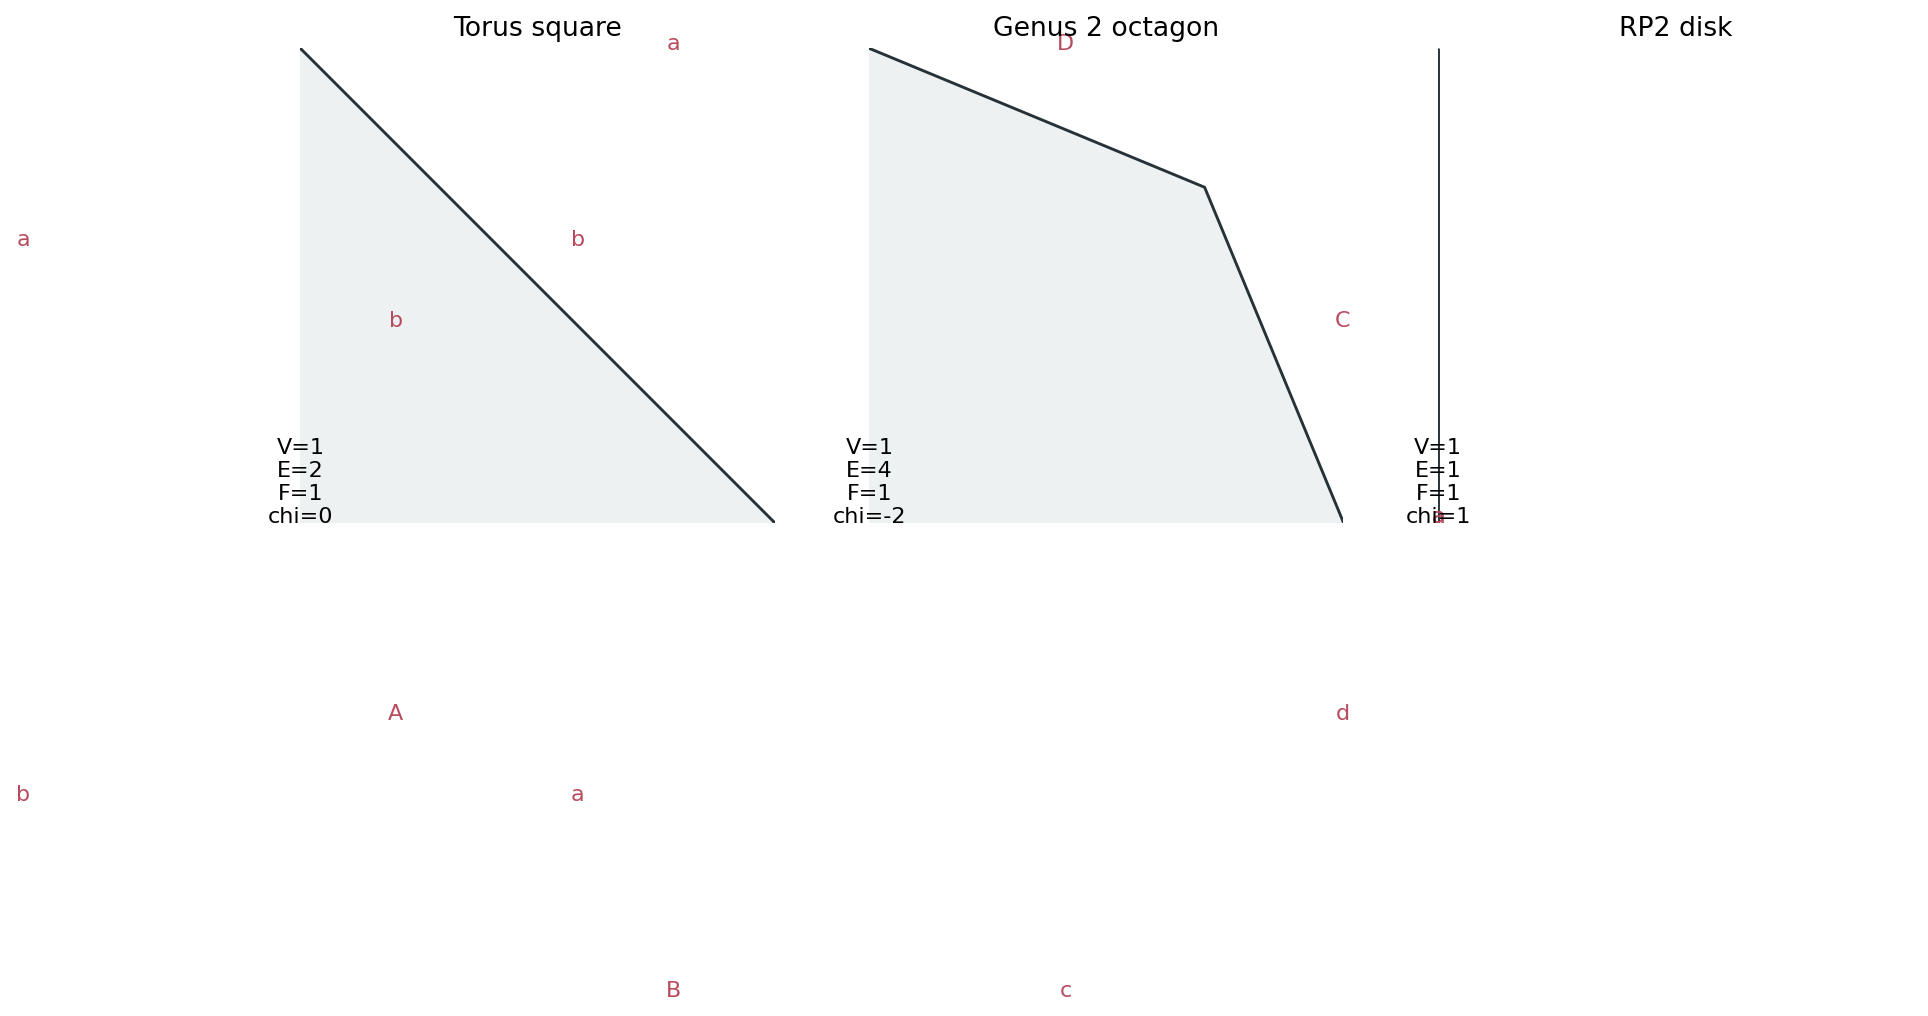

D:\Geometry\.venv\Lib\site-packages\IPython\core\display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


In [4]:
# Quotient models: torus, genus two surface, and RP2.
fig,axes=plt.subplots(1,3,figsize=(13,4.2)); models=[('Torus square',['a','b','a','b'],{'V':1,'E':2,'F':1,'chi':0}),('Genus 2 octagon',['a','b','A','B','c','d','C','D'],{'V':1,'E':4,'F':1,'chi':-2}),('RP2 disk',['a','a'],{'V':1,'E':1,'F':1,'chi':1})]
for ax,(title,labs,cnts) in zip(axes,models):
    n=len(labs); th=np.linspace(np.pi/2,np.pi/2+2*np.pi,n,endpoint=False); pts=np.c_[np.cos(th),np.sin(th)]
    ax.add_patch(Polygon(pts,closed=True,facecolor='#edf1f2',edgecolor=PAL['ink'],lw=1.3))
    for i,lab in enumerate(labs):
        p=(pts[i]+pts[(i+1)%n])/2; ax.text(1.17*p[0],1.17*p[1],lab,color=PAL['red'],ha='center')
    ax.text(0,0,f"V={cnts['V']}\nE={cnts['E']}\nF={cnts['F']}\nchi={cnts['chi']}",ha='center'); ax.set_title(title); ax.set_aspect('equal'); ax.axis('off')
surface_path=track(save_matplotlib(fig,FIGURES/'surface-polygon-quotients.png')); plt.close(fig)
surface_checks={title:cnts for title,_,cnts in models}; surface_checks['genus2_chi_formula']=2-2*2; surface_check_path=track(save_json(surface_checks,CHECKS/'surface-polygon-quotients.json')); checks['surface']=surface_checks
display_artifact(surface_path,width=900)

# Space operation lab.
t=np.linspace(0,2*np.pi,160); fig=go.Figure(); fig.add_trace(go.Scatter3d(x=np.cos(t)-3,y=np.sin(t),z=0*t,mode='lines',name='X=S1',line=dict(color='#2f8f83',width=5)))
for a in np.linspace(0,2*np.pi,12,endpoint=False): fig.add_trace(go.Scatter3d(x=[np.cos(a)-1,-1],y=[np.sin(a),0],z=[0,1.25],mode='lines',showlegend=False,line=dict(color='rgba(185,75,95,.45)',width=3)))
fig.add_trace(go.Scatter3d(x=np.cos(t)-1,y=np.sin(t),z=0*t,mode='lines',name='cone base',line=dict(color='#b94b5f',width=4)))
for pole in [-1.1,1.1]:
    for a in np.linspace(0,2*np.pi,8,endpoint=False): fig.add_trace(go.Scatter3d(x=[np.cos(a)+1.2,1.2],y=[np.sin(a),0],z=[0,pole],mode='lines',showlegend=False,line=dict(color='rgba(59,110,168,.35)',width=2)))
fig.add_trace(go.Scatter3d(x=np.cos(t)+1.2,y=np.sin(t),z=0*t,mode='lines',name='suspension equator',line=dict(color='#3b6ea8',width=4)))
fig.add_trace(go.Scatter3d(x=.55*np.cos(t)+3.4,y=.55*np.sin(t),z=0*t,mode='lines',name='wedge lobe 1',line=dict(color='#d99b2b',width=5))); fig.add_trace(go.Scatter3d(x=.55*np.cos(t)+4.5,y=.55*np.sin(t),z=0*t,mode='lines',name='wedge lobe 2',line=dict(color='#d99b2b',width=5)))
fig.update_layout(title='Operation lab: X, cone CX, suspension SX, wedge X v X',width=900,height=580,scene=dict(xaxis_title='panel',yaxis_title='space coordinate',zaxis_title='quotient direction'),margin=dict(l=0,r=0,t=55,b=0))
ops_path=track(save_plotly_html(fig,HTML/'space-operations-lab.html')); ops_checks={'cone_tip_unique':True,'suspension_has_two_cone_points':True,'wedge_basepoints_identified':True}; ops_check_path=track(save_json(ops_checks,CHECKS/'space-operations-lab.json')); checks['operations']=ops_checks
display_artifact(ops_path,width=840,height=540)


## 3. Collapse Criteria, Mapping Cones, And HEP

Collapsing a contractible subcomplex is useful only under controlled hypotheses. Mapping cylinders, mapping cones, and the homotopy extension property are the proof tools that keep this control visible.


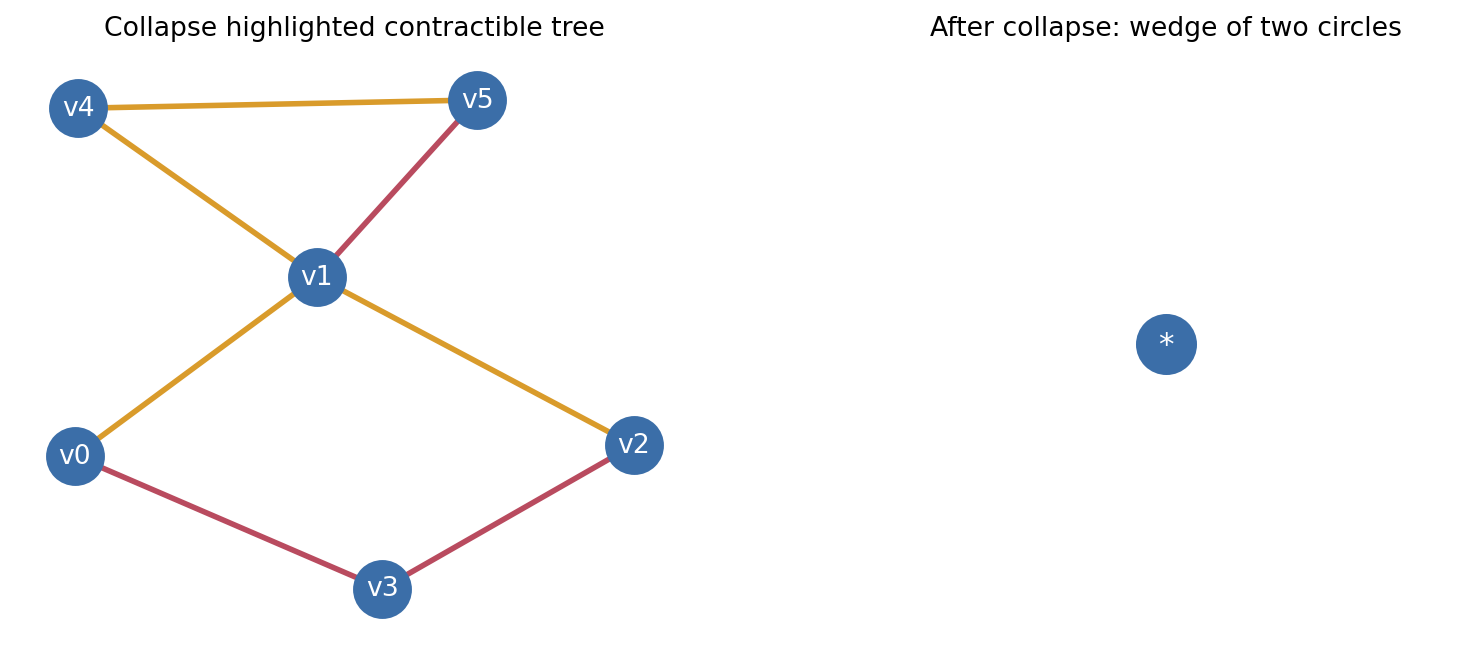

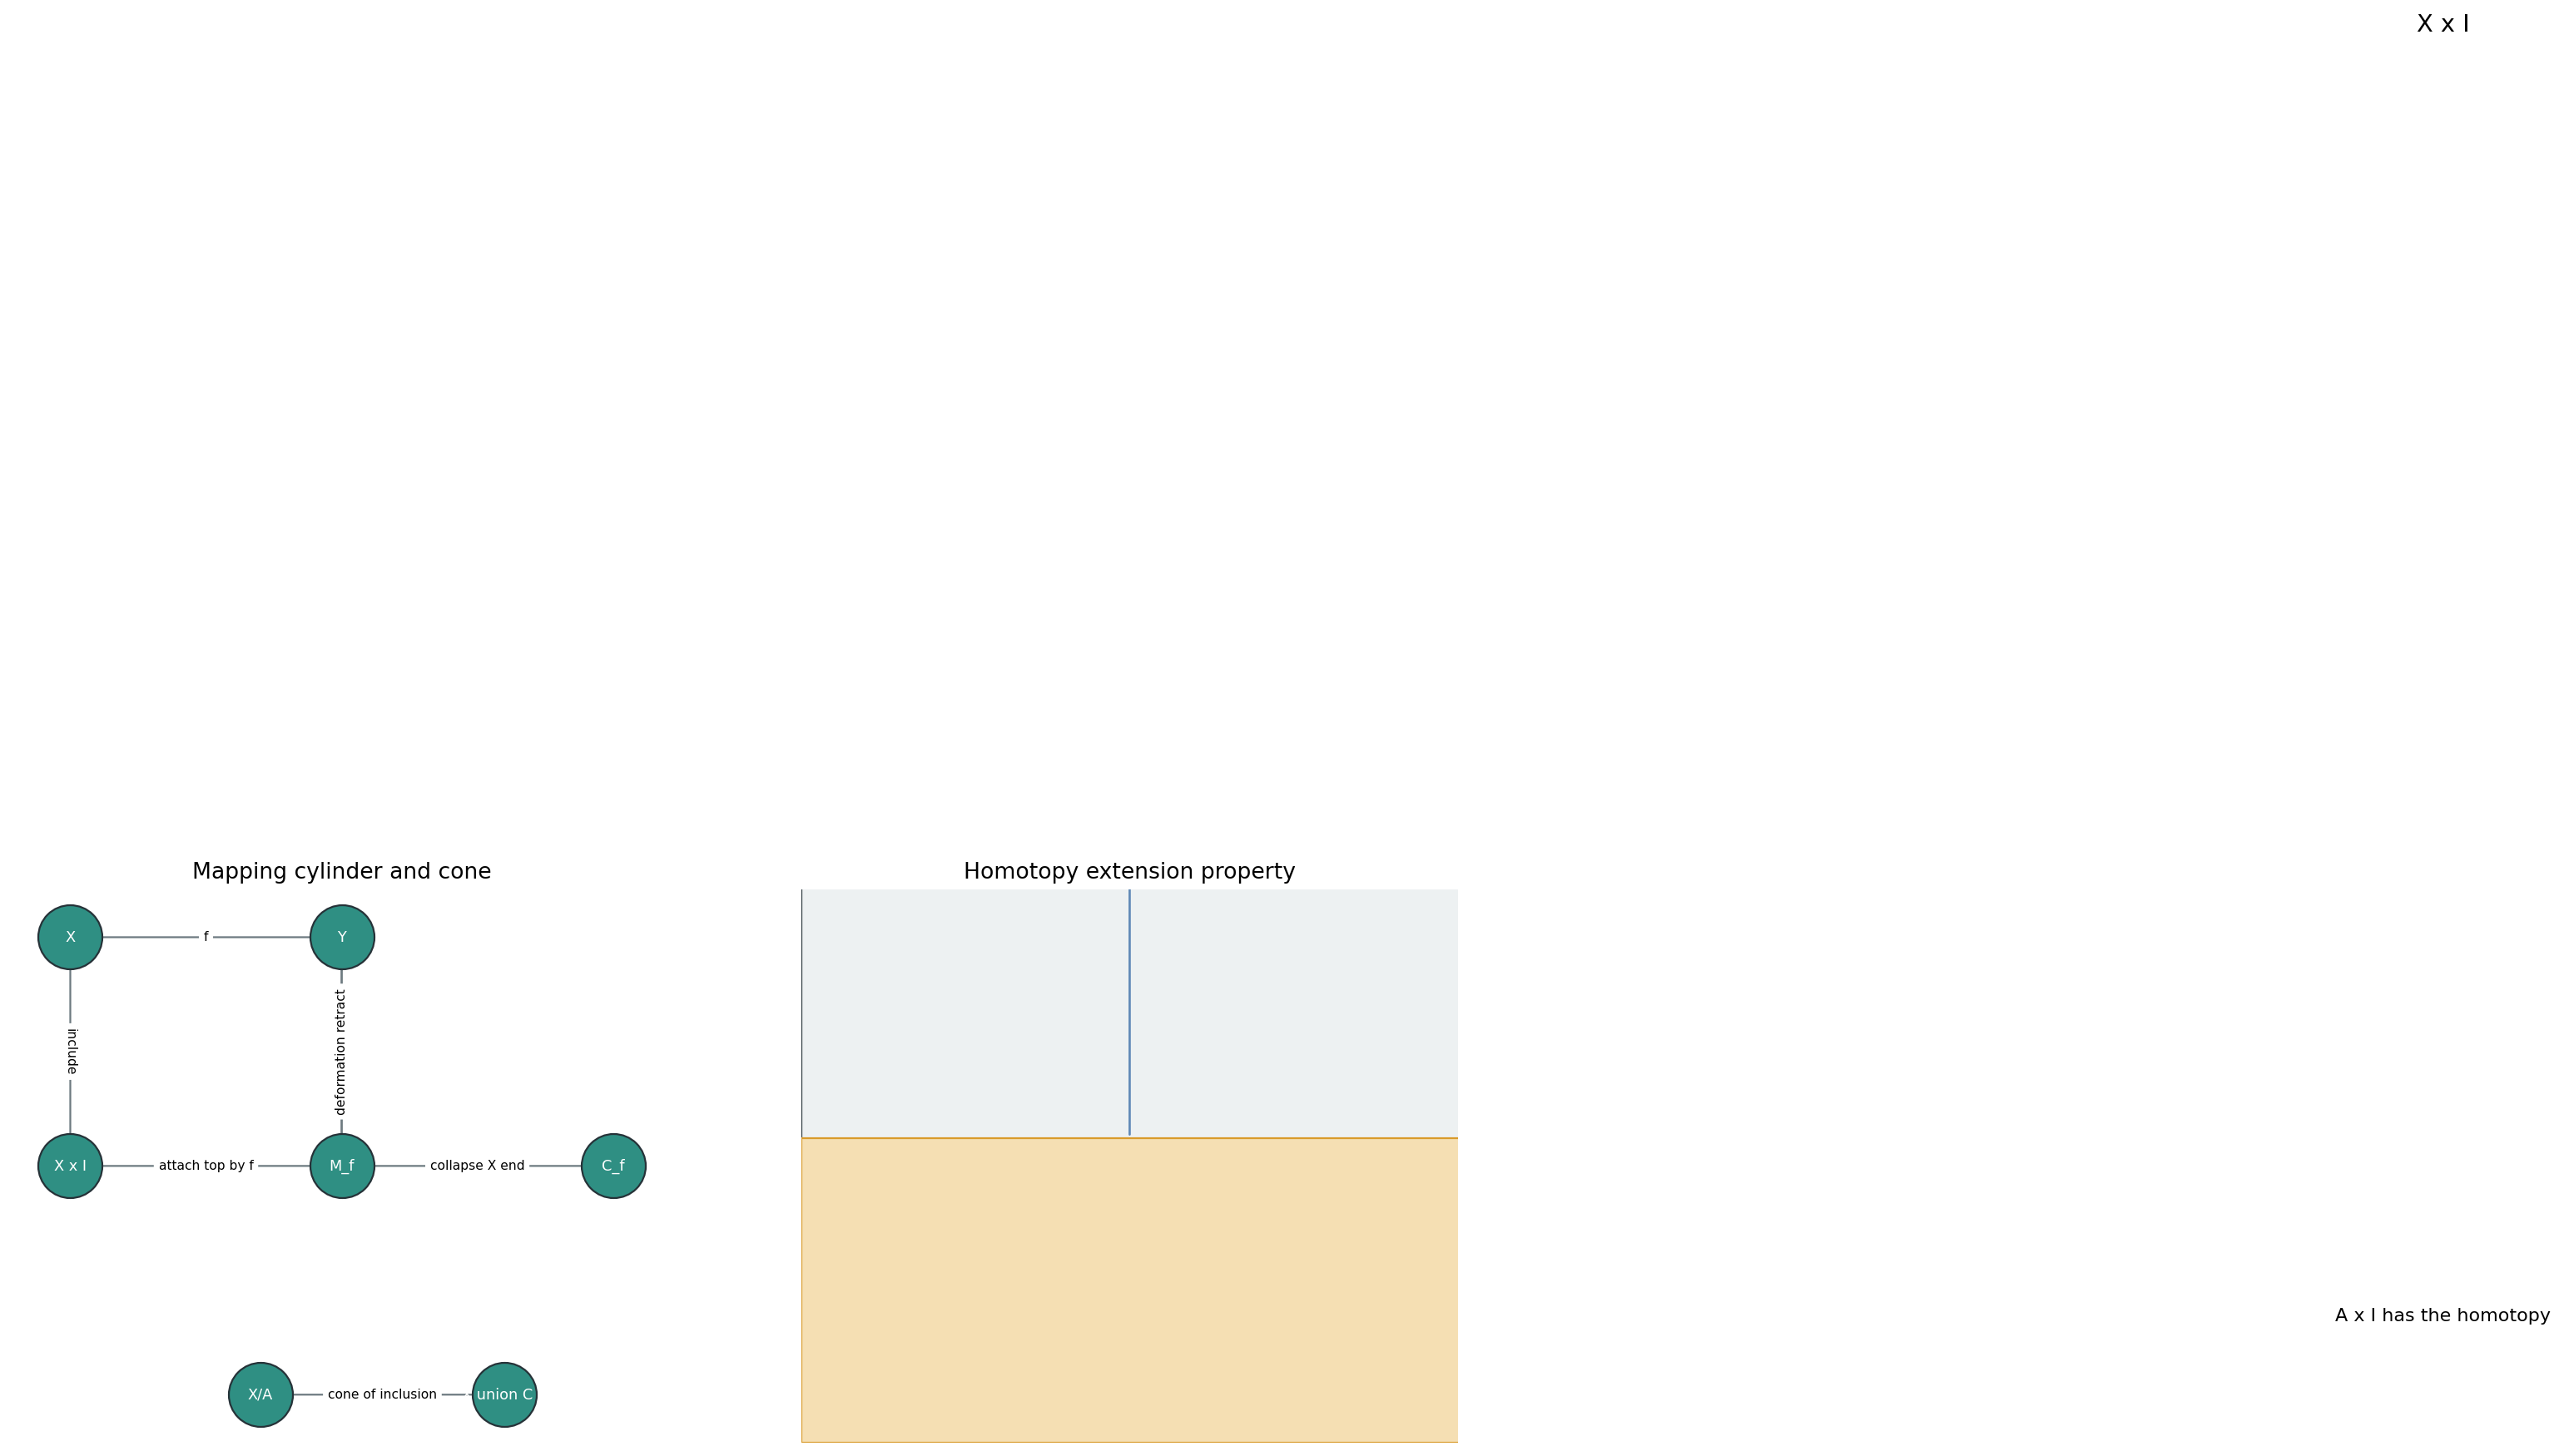

In [5]:
# Collapsing a contractible tree in a graph preserves free rank.
G0=nx.Graph(); G0.add_edges_from([('v0','v1'),('v1','v2'),('v2','v3'),('v3','v0'),('v1','v4'),('v4','v5'),('v5','v1')]); T=[('v0','v1'),('v1','v2'),('v1','v4'),('v4','v5')]
rank_before=G0.number_of_edges()-G0.number_of_nodes()+1; rank_after=rank_before; pos0=nx.spring_layout(G0,seed=7)
fig,axes=plt.subplots(1,2,figsize=(12,4.8)); nx.draw_networkx(G0,pos0,ax=axes[0],edge_color=[PAL['gold'] if tuple(e) in T or tuple(reversed(e)) in T else PAL['red'] for e in G0.edges],node_color=PAL['blue'],font_color='white',width=2.5,node_size=650); axes[0].set_title('Collapse highlighted contractible tree')
for rad,col in [(0.35,PAL['red']),(-0.35,PAL['teal'])]: axes[1].add_patch(FancyArrowPatch((0,0),(.01,.01),connectionstyle=f'arc3,rad={rad}',arrowstyle='->',mutation_scale=18,lw=4,color=col))
axes[1].scatter([0],[0],s=700,color=PAL['blue']); axes[1].text(0,0,'*',ha='center',va='center',color='white',fontsize=14); axes[1].set_title('After collapse: wedge of two circles'); axes[1].set_xlim(-1,1); axes[1].set_ylim(-1,1); axes[1].set_aspect('equal')
for a in axes: a.axis('off')
collapse_path=track(save_matplotlib(fig,FIGURES/'collapsing-subcomplexes-invariants.png')); plt.close(fig)
collapse_checks={'rank_before':int(rank_before),'rank_after':int(rank_after),'tree_contractible':len(T)==5-1}; collapse_check_path=track(save_json(collapse_checks,CHECKS/'collapsing-subcomplexes-invariants.json')); checks['collapse']=collapse_checks
display_artifact(collapse_path,width=820)

# Mapping cylinder/cone diagram and HEP collar panel.
DG=nx.DiGraph(); [DG.add_edge(u,v,label=l) for u,v,l in [('X','Y','f'),('X','X x I','include'),('X x I','M_f','attach top by f'),('Y','M_f','include'),('M_f','Y','deformation retract'),('M_f','C_f','collapse X end'),('X/A','X union C A','cone of inclusion')]]
pos={'X':(-2,.6),'Y':(0,.6),'X x I':(-2,-.6),'M_f':(0,-.6),'C_f':(2,-.6),'X/A':(-.6,-1.8),'X union C A':(1.2,-1.8)}; fig,axes=plt.subplots(1,2,figsize=(14,5.4))
nx.draw_networkx_edges(DG,pos,ax=axes[0],arrows=True,edge_color=PAL['gray']); nx.draw_networkx_nodes(DG,pos,ax=axes[0],node_color=PAL['teal'],node_size=1200,edgecolors=PAL['ink']); nx.draw_networkx_labels(DG,pos,ax=axes[0],font_size=8,font_color='white'); nx.draw_networkx_edge_labels(DG,pos,nx.get_edge_attributes(DG,'label'),ax=axes[0],font_size=7); axes[0].set_title('Mapping cylinder and cone'); axes[0].axis('off')
axes[1].add_patch(Rectangle((0,0),5,3,facecolor='#edf1f2',edgecolor=PAL['ink'])); axes[1].add_patch(Rectangle((0,0),5,.55,facecolor='#f5dfb3',edgecolor=PAL['gold'])); axes[1].text(2.5,2.55,'X x I',ha='center',fontsize=13); axes[1].text(2.5,.22,'A x I has the homotopy',ha='center');
for x in np.linspace(.5,4.5,7): axes[1].add_patch(FancyArrowPatch((x,.55),(x,2.25),arrowstyle='->',mutation_scale=12,lw=1.2,color=PAL['blue'],alpha=.8))
axes[1].axis('off'); axes[1].set_title('Homotopy extension property')
proof_path=track(save_matplotlib(fig,FIGURES/'mapping-cylinder-cone-and-hep.png')); plt.close(fig)
proof_checks={'mapping_cylinder_retracts_to_Y':True,'cone_collapses_source_end':True,'relative_homotopy_tracks_A':True}; proof_check_path=track(save_json(proof_checks,CHECKS/'mapping-cylinder-cone-and-hep.json')); checks['proof_tools']=proof_checks
display_artifact(proof_path,width=920)


## Applied Lab

Change the number of genus handles or collapse-tree data. Polygon quotient cell counts change Euler characteristic, while collapsing a tree in a connected graph preserves free rank.


In [6]:
def chapter0_lab(genus=3, vertices=7, edges=10, tree_edges=6):
    rank=edges-vertices+1
    return {'genus':genus,'surface_euler_characteristic':2-2*genus,'tree_collapse_preserves_rank':tree_edges==vertices-1,'free_rank_after_tree_collapse':rank}
lab_report=chapter0_lab(); lab_path=track(save_json(lab_report,CHECKS/'chapter0-applied-lab.json')); checks['lab']=lab_report
display(Markdown('`chapter0-applied-lab.json` records a genus/collapse parameter check.'))

# final_sanity
final_required=[routing_path,roadmap_path,roadmap_check_path,cw_path,cw_check_path,surface_path,surface_check_path,ops_path,ops_check_path,collapse_path,collapse_check_path,proof_path,proof_check_path,lab_path]
assert_artifacts(final_required,min_bytes=40)
assert SOURCE_PRINTED==(1,20)
assert roadmap_checks['has_HEP_path']
assert cw_checks['boundary_squared_zero'] and cw_checks['euler_characteristic']==1
assert surface_checks['genus2_chi_formula']==-2
assert ops_checks['cone_tip_unique'] and ops_checks['wedge_basepoints_identified']
assert collapse_checks['tree_contractible'] and collapse_checks['rank_before']==collapse_checks['rank_after']
assert proof_checks['mapping_cylinder_retracts_to_Y'] and proof_checks['relative_homotopy_tracks_A']
summary_path=track(save_json({'unit':UNIT_TITLE,'all_checks_passed':True,'artifact_count':len(final_required),'checks':checks},CHECKS/'chapter0-core-checks.json'))
print(f'Chapter 0 sanity passed with {len(final_required)} artifacts plus summary.')


`chapter0-applied-lab.json` records a genus/collapse parameter check.

Chapter 0 sanity passed with 14 artifacts plus summary.


## Takeaways

- Homotopy type is the chapter's license to replace a space by a simpler model.
- CW complexes make this replacement inspectable one cell at a time.
- Quotient operations are powerful, but their hypotheses matter.
- Mapping cylinders, mapping cones, and HEP are proof scaffolds used throughout algebraic topology.
